In [1]:
import pandas as pd
from sqlalchemy import create_engine
import geopandas as gpd
from dotenv import load_dotenv
load_dotenv()

import os

# Database connection details from zshrc environment variables
#  use .env file for local development


db_name = 'colorado_spills'
user = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')


# Create an engine to connect to the PostgreSQL database
engine = create_engine(f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{db_name}')

# Read in the spills_with_demographics_geog as spills
spills = pd.read_sql_table('spills_with_demographics_geog', engine)



ModuleNotFoundError: No module named 'geopandas'

In [ ]:
# use longitude and latitude to create a GeoDataFrame from spills data
spills['geometry'] = gpd.points_from_xy(spills['Longitude'], spills['Latitude'])

In [ ]:
spills_gdf = gpd.GeoDataFrame(spills, crs='EPSG:4326') 


In [ ]:

# Ensure date columns are in datetime format
spills_gdf['Date of Discovery'] = pd.to_datetime(spills_gdf['Date of Discovery'])
spills_gdf['Initial Report Date'] = pd.to_datetime(spills_gdf['Initial Report Date'])



In [ ]:
# Separate Historical vs. Recent Spills
historical_spills = spills_gdf[spills_gdf['Spill Type'] == 'Historical']
recent_spills = spills_gdf[spills_gdf['Spill Type'] == 'Recent']


In [ ]:
# Compare Reporting Delay
report_delay_summary = spills_gdf.groupby('Spill Type')['Report Delay (Days)'].describe()
print(report_delay_summary)


              count       mean         std  min  25%  50%  75%     max
Spill Type                                                            
Historical   5828.0  20.987646  205.864644  0.0  0.0  1.0  2.0  9261.0
Recent      11062.0   4.075484   46.649970  0.0  0.0  1.0  2.0  2232.0


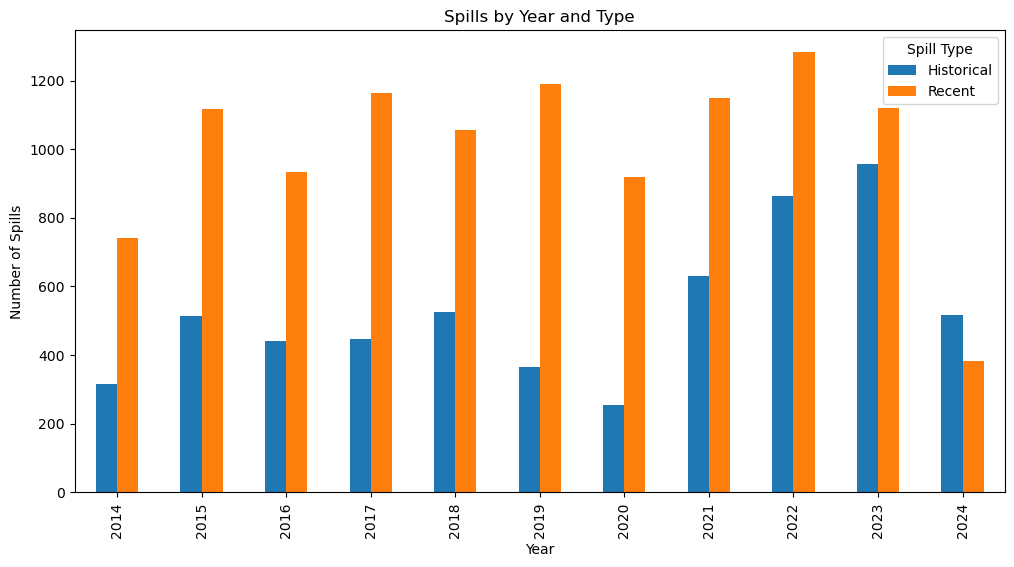

In [ ]:
import matplotlib.pyplot as plt

# Compare Spill Trends Over Time
spills_by_year = spills_gdf.groupby(['Report Year', 'Spill Type']).size().unstack()
spills_by_year.plot(kind='bar', figsize=(12,6), title='Spills by Year and Type')
plt.xlabel('Year')
plt.ylabel('Number of Spills')
plt.legend(title='Spill Type')
plt.show()

In [ ]:

# Operator Performance Analysis
operator_analysis = spills_gdf.groupby(['Operator', 'Spill Type'])['Report Delay (Days)'].mean().unstack()
operator_analysis['Total Spills'] = spills_gdf.groupby('Operator').size()
operator_analysis = operator_analysis.sort_values(by='Total Spills', ascending=False)
print(operator_analysis.head(10))


Spill Type                                  Historical     Recent  \
Operator                                                            
NOBLE ENERGY INC                              2.506479   1.448166   
KERR MCGEE OIL & GAS ONSHORE LP               6.273743  11.311961   
PDC ENERGY INC                                3.349296   2.347458   
CAERUS PICEANCE LLC                          10.082090   0.980371   
BONANZA CREEK ENERGY OPERATING COMPANY LLC   65.785714   1.126065   
KP KAUFFMAN COMPANY INC                      58.846154   8.448276   
CHEVRON USA INC                             251.076923   2.180723   
HIGHPOINT OPERATING CORPORATION               1.027778   0.922667   
CRESTONE PEAK RESOURCES OPERATING LLC         1.662420   0.962025   
LARAMIE ENERGY LLC                           23.833333   1.707386   

Spill Type                                  Total Spills  
Operator                                                  
NOBLE ENERGY INC                                    2

In [ ]:
# Operator comparison of historical vs recent spills
operator_spill_type = spills_gdf.groupby(['Operator', 'Spill Type']).size().unstack()
operator_spill_type['Total Spills'] = operator_spill_type.sum(axis=1)
print(operator_spill_type.sort_values(by='Total Spills', ascending=False).head(10))


Spill Type                                  Historical  Recent  Total Spills
Operator                                                                    
NOBLE ENERGY INC                                1775.0   627.0        2402.0
KERR MCGEE OIL & GAS ONSHORE LP                 1432.0   811.0        2243.0
PDC ENERGY INC                                   710.0   472.0        1182.0
CAERUS PICEANCE LLC                              134.0   917.0        1051.0
BONANZA CREEK ENERGY OPERATING COMPANY LLC        56.0   587.0         643.0
KP KAUFFMAN COMPANY INC                           91.0   377.0         468.0
CHEVRON USA INC                                   52.0   415.0         467.0
HIGHPOINT OPERATING CORPORATION                   36.0   375.0         411.0
CRESTONE PEAK RESOURCES OPERATING LLC            157.0   237.0         394.0
LARAMIE ENERGY LLC                                24.0   352.0         376.0


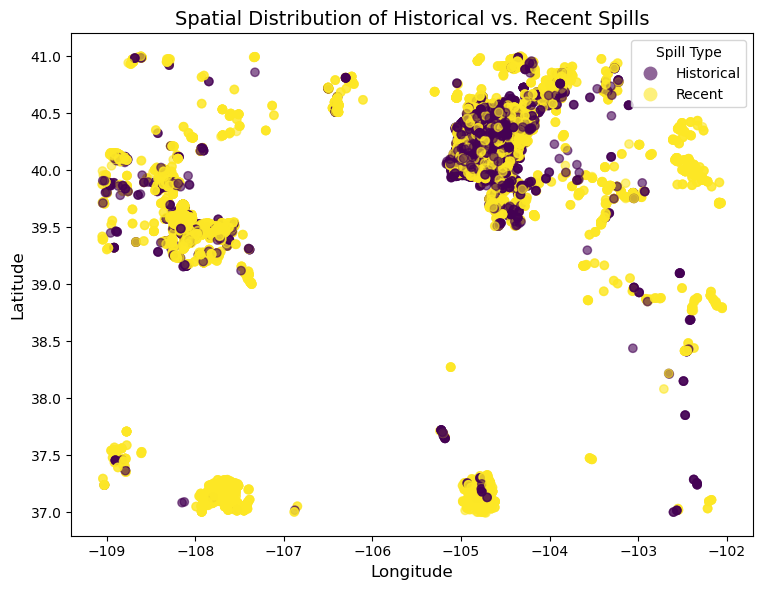

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd

# Ensure spills_gdf is already a GeoDataFrame with the necessary data
# spills_gdf = gpd.GeoDataFrame(...)

# Create a plot for the spatial distribution of spills
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the GeoDataFrame with optimizations
spills_gdf.plot(
    ax=ax,
    marker='o', 
    alpha=0.6,  # Adjust transparency for better visibility
    column='Spill Type', 
    legend=True, 
    legend_kwds={'title': "Spill Type"},  # Correctly specify the legend title
    cmap='viridis'  # Use a colormap for better visual distinction
)

# Set plot title and labels
ax.set_title('Spatial Distribution of Historical vs. Recent Spills', fontsize=14)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

# Improve layout
plt.tight_layout()

# Display the plot
plt.show()


In [ ]:
# Add a column to indicate whether the spill occurred before or after 2021
spills_gdf['Period'] = spills_gdf['Report Year'].apply(lambda x: 'Before 2021' if x < 2021 else '2021 and After')

# Group by the new period column and calculate the mean response time
response_time_summary = spills_gdf.groupby('Period')['Report Delay (Days)'].describe()
print(response_time_summary)

                 count       mean         std  min  25%  50%  75%     max
Period                                                                   
2019 and After  9633.0   8.893595  146.187118  0.0  0.0  1.0  1.0  9261.0
Before 2019     7257.0  11.261816   95.550903  0.0  1.0  1.0  2.0  2059.0


T-Statistic: 1.2701
P-Value: 0.2041
The difference in response time is not statistically significant.


<Axes: title={'center': 'Report Delay (Days)'}, xlabel='Period'>

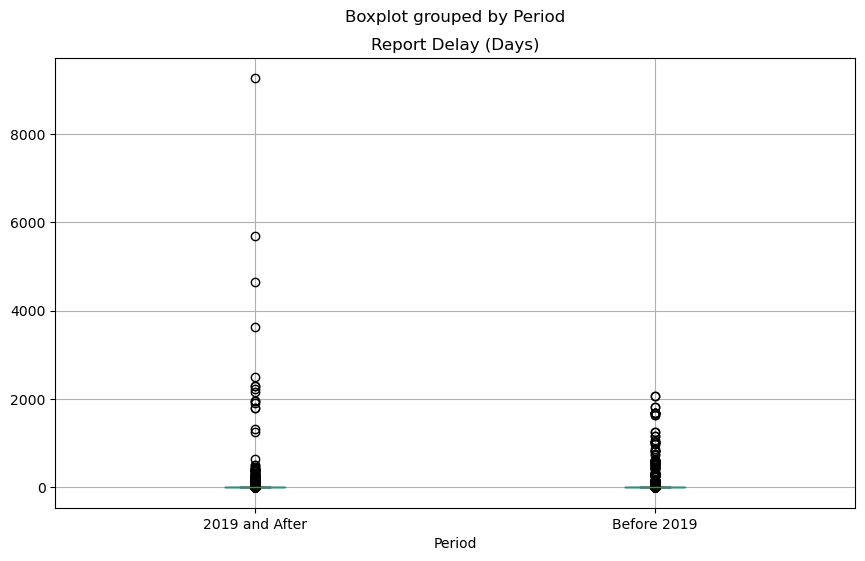

In [ ]:
# t-test for the difference in response time before and after 2021
from scipy.stats import ttest_ind

before_2021 = spills_gdf[spills_gdf['Period'] == 'Before 2021']['Report Delay (Days)']
after_2021 = spills_gdf[spills_gdf['Period'] == '2021 and After']['Report Delay (Days)']

t_stat, p_value = ttest_ind(before_2021, after_2021, equal_var=False)
print(f'T-Statistic: {t_stat:.4f}')
print(f'P-Value: {p_value:.4f}')

# Check if the difference is statistically significant
if p_value < 0.05:
    print('The difference in response time is statistically significant.')
else:
    print('The difference in response time is not statistically significant.')
    
# Create a plot for the response time distribution before and after 2021
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the response time distribution for each period
spills_gdf.boxplot(column='Report Delay (Days)', by='Period', ax=ax)




In [ ]:
# Add a column to indicate whether the spill occurred before or after 2021 for historical and recent spills
historical_spills['Period'] = historical_spills['Report Year'].apply(lambda x: 'Before 2021' if x < 2021 else '2021 and After')
recent_spills['Period'] = recent_spills['Report Year'].apply(lambda x: 'Before 2021' if x < 2021 else '2021 and After')

# Historical Spills Analysis
historical_report_delay_summary = historical_spills['Report Delay (Days)'].describe()
print("Historical Spills Report Delay Summary:")
print(historical_report_delay_summary)

# Recent Spills Analysis
recent_report_delay_summary = recent_spills['Report Delay (Days)'].describe()
print("\nRecent Spills Report Delay Summary:")
print(recent_report_delay_summary)

# Historical Spills Response Time Summary
historical_response_time_summary = historical_spills.groupby('Period')['Report Delay (Days)'].describe()
print("\nHistorical Spills Response Time Summary:")
print(historical_response_time_summary)

# Recent Spills Response Time Summary
recent_response_time_summary = recent_spills.groupby('Period')['Report Delay (Days)'].describe()
print("\nRecent Spills Response Time Summary:")
print(recent_response_time_summary)

Historical Spills Report Delay Summary:
count    5828.000000
mean       20.987646
std       205.864644
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max      9261.000000
Name: Report Delay (Days), dtype: float64

Recent Spills Report Delay Summary:
count    11062.000000
mean         4.075484
std         46.649970
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max       2232.000000
Name: Report Delay (Days), dtype: float64

Historical Spills Response Time Summary:
                 count       mean         std  min  25%  50%  75%     max
Period                                                                   
2019 and After  3586.0  16.696319  228.183311  0.0  0.0  0.0  1.0  9261.0
Before 2019     2242.0  27.851472  163.784495  0.0  1.0  1.0  2.0  2059.0

Recent Spills Response Time Summary:
                 count      mean        std  min  25%  50%  75%     max
Period                                         

/home/dadams/miniconda3/envs/spatial_env2/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/dadams/miniconda3/envs/spatial_env2/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
